In [7]:
using Pkg
Pkg.activate("CIG_Practice")

# Pkg.add(["ImageGather", "PythonPlot", "IterativeSolvers", "LinearAlgebra", "Statistics", "Random"])
# Pkg.add(name="JUDI", version="3.3.8")
# Pkg.add(name="ImageGather", version="0.2.6")

using JUDI
using PythonPlot
using PythonCall: pyconvert
using ImageGather
using Images
using LinearAlgebra
using IterativeSolvers
using Statistics
using Random

  Activating project at `~/Downloads/CIG_Practice`
[ Info: Precompiling JUDI [f3b833dc-6b2e-5b9c-b940-873ed6319979]
[ Info: Precompiling PythonPlot [274fc56d-3b97-40fa-a1cd-1b4a50311bf9]
[ Info: Precompiling ImageGather [355d8124-6b2e-49b5-aab5-cdbc0a5fccbe]
[ Info: JLD2 compat enabled


In [8]:
## Acquisition set-up
startidx = 1
endidx = 1000
n_offsets = 51
offset_start = -300
offset_end = 300

offsetrange = range(offset_start, stop=offset_end, length=n_offsets)

f0 = 0.018f0
timeD = timeR = TD = 2000f0
dtD = 4f0
dtS = 4f0
nbl = 80

wavelet = ricker_wavelet(TD, dtS, f0)
#wavelet = filter_data(wavelet, dtS; fmin=3f0, fmax=Inf)

d = (12.5f0, 12.5f0)
o = (0f0, 0f0)
n = (256, 128)

snr = 15f0
nsrc = 16	# number of sources
nrec = n[1]

# Set up receiver structure
xrec = range(0f0, stop=(n[1]-1)*d[1], length=nrec)
yrec = 0f0 # WE have to set the y coordiante to zero (or any number) for 2D modeling
zrec = range(d[1], stop=d[1], length=nrec)

recGeometry = Geometry(xrec, yrec, zrec; dt=dtD, t=timeD, nsrc=nsrc)

# Set up source structure
xsrc = convertToCell(range(0f0,stop=(n[1]-1)*d[1],length=nsrc))
ysrc = convertToCell(range(0f0, stop=0f0, length=nsrc))
zsrc = convertToCell(range(d[1], stop=d[1], length=nsrc))

srcGeometry = Geometry(xsrc, ysrc, zsrc; dt=dtD, t=timeD)

q = judiVector(srcGeometry, wavelet)
opt = Options(isic=false)

JUDI Options : 

space_order               :          8
free_surface              :      false
limit_m                   :      false
buffer_size               :     1000.0
save_data_to_disk         :      false
file_path                 :           
file_name                 :       shot
sum_padding               :      false
optimal_checkpointing     :      false
frequencies               :      Any[]
IC                        :         as
subsampling_factor        :          1
dft_subsampling_factor    :          1
return_array              :      false
dt_comp                   :    nothing
f0                        :      0.015


In [9]:
## Velocity model
vp = zeros(Float32, 256,128);
vp0 = zeros(Float32, 256,128);
rho = zeros(Float32, 256,128);
vp .= 2.0;
vp[:,65:66] .= 2.5;
vp0 .= 2.0;
#vp0 = 1f0./imfilter(1f0./vp, Kernel.gaussian(20))

## density model
# rho[:,1:64] .= 2.0;
# rho[:,65:end] .= 2.0;
#rho0 = imfilter(rho, Kernel.gaussian(10))
# model_p = Model(n, d, o, (1f0./vp).^2f0; rho=rho, nb=nbl)
# model_p0 = Model(n, d, o, (1f0./vp0).^2f0; rho=rho0, nb=nbl)
model = Model(n, d, o, (1f0./vp).^2f0; nb=nbl)
model0 = Model(n, d, o, (1f0./vp0).^2f0; nb=nbl)
dm = model.m - model0.m;

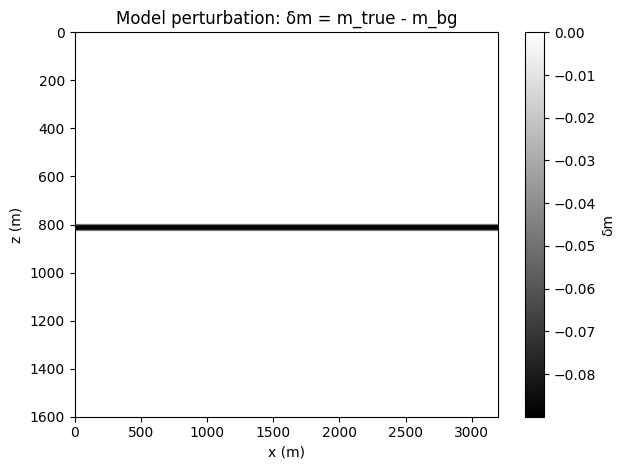

Python: None

In [10]:
imshow(dm.data', cmap="gray", aspect="auto",
       extent=[0, n[1]*d[1], n[2]*d[2], 0])
colorbar(label="δm")
xlabel("x (m)")
ylabel("z (m)")
title("Model perturbation: δm = m_true - m_bg")
tight_layout()

In [11]:
F = judiModeling(model, srcGeometry, recGeometry, options=opt)
F0 = judiModeling(model0, srcGeometry, recGeometry, options=opt)

J = judiJacobian(F0, q)
J_ext = judiExtendedJacobian(F0, q, offsetrange)
dm_ext = zeros(Float32, n_offsets, n...)
dm_ext[26,:,:] = dm
@time dlin = J * dm
#@time dlin_ext = J_ext * dm_ext

┌ Warning: Deprecated model.n, use size(model)
│   caller = ip:0x0
└ @ Core :-1
Building born operator
Operator `born` ran in 0.07 s
Operator `born` ran in 0.13 s
Operator `born` ran in 0.10 s
Operator `born` ran in 0.12 s
Operator `born` ran in 0.10 s
Operator `born` ran in 0.10 s
Operator `born` ran in 0.14 s
Operator `born` ran in 0.11 s
Operator `born` ran in 0.10 s
Operator `born` ran in 0.09 s
Operator `born` ran in 0.08 s
Operator `born` ran in 0.09 s
Operator `born` ran in 0.10 s
Operator `born` ran in 0.09 s
Operator `born` ran in 0.08 s
Operator `born` ran in 0.09 s


 22.212305 seconds (22.95 M allocations: 1.245 GiB, 15.72% gc time, 34.51% compilation time: 1% of which was recompilation)


judiVector{Float32, Matrix{Float32}} with 16 sources


In [12]:
@time dlin_ext = J_ext * dm_ext

 42.730819 seconds (3.56 M allocations: 268.030 MiB, 0.10% gc time, 3.36% compilation time)


Operator `extborn` ran in 0.85 s
Operator `extborn` ran in 0.85 s
Operator `extborn` ran in 0.92 s
Operator `extborn` ran in 0.89 s
Operator `extborn` ran in 0.88 s
Operator `extborn` ran in 0.88 s
Operator `extborn` ran in 0.88 s
Operator `extborn` ran in 0.94 s
Operator `extborn` ran in 0.96 s
Operator `extborn` ran in 0.86 s
Operator `extborn` ran in 0.91 s
Operator `extborn` ran in 0.97 s
Operator `extborn` ran in 1.01 s
Operator `extborn` ran in 0.90 s
Operator `extborn` ran in 0.95 s
Operator `extborn` ran in 0.87 s


judiVector{Float32, Matrix{Float32}} with 16 sources


In [13]:
data_extent = [xrec[1], xrec[end], 1f-3*timeR, 0];

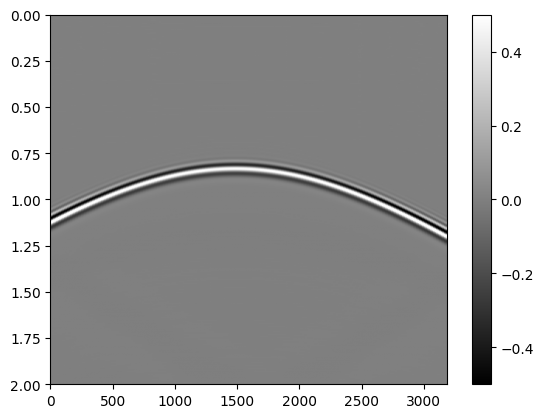

Python: None

In [14]:
imshow(dlin.data[8], vmin=-0.5, vmax=0.5, cmap="gray", aspect="auto", extent=data_extent);colorbar()
savefig("J*dm_standard")

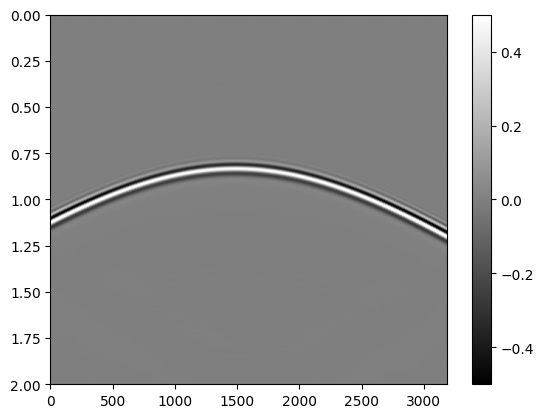

Python: None

In [15]:
imshow(dlin_ext.data[8], vmin=-0.5, vmax=0.5, cmap="gray", aspect="auto", extent=data_extent);colorbar()
savefig("J_ext*dm_ext_extended")

In [17]:
rtm_lin = J'*dlin

Building forward operator
Operator `forward` ran in 0.04 s
Building adjoint born operator
Operator `gradient` ran in 0.05 s
Operator `forward` ran in 0.04 s
Operator `gradient` ran in 0.05 s
Operator `forward` ran in 0.04 s
Operator `gradient` ran in 0.06 s
Operator `forward` ran in 0.04 s
Operator `gradient` ran in 0.06 s
Operator `forward` ran in 0.04 s
Operator `gradient` ran in 0.06 s
Operator `forward` ran in 0.04 s
Operator `gradient` ran in 0.06 s
Operator `forward` ran in 0.04 s
Operator `gradient` ran in 0.06 s
Operator `forward` ran in 0.04 s
Operator `gradient` ran in 0.05 s
Operator `forward` ran in 0.04 s
Operator `gradient` ran in 0.06 s
Operator `forward` ran in 0.04 s
Operator `gradient` ran in 0.06 s
Operator `forward` ran in 0.04 s
Operator `gradient` ran in 0.06 s
Operator `forward` ran in 0.04 s
Operator `gradient` ran in 0.06 s
Operator `forward` ran in 0.04 s
Operator `gradient` ran in 0.06 s
Operator `forward` ran in 0.04 s
Operator `gradient` ran in 0.05 s
Opera

PhysicalParameter{Float32, 2} of size (256, 128) with origin (0.0f0, 0.0f0) and spacing (12.5f0, 12.5f0)


In [18]:
cig_lin = J_ext'*dlin_ext

Building forward operator
Operator `forward` ran in 0.04 s
Operator `cig_sso` ran in 1.25 s
┌ Warning: Deprecated model.d, use spacing(model)
│   caller = ip:0x0
└ @ Core :-1
┌ Warning: Deprecated model.o, use origin(model)
│   caller = ip:0x0
└ @ Core :-1
Operator `forward` ran in 0.04 s
Operator `cig_sso` ran in 1.28 s
Operator `forward` ran in 0.04 s
Operator `cig_sso` ran in 1.25 s
Operator `forward` ran in 0.04 s
Operator `cig_sso` ran in 1.22 s
Operator `forward` ran in 0.04 s
Operator `cig_sso` ran in 1.27 s
Operator `forward` ran in 0.04 s
Operator `cig_sso` ran in 1.27 s
Operator `forward` ran in 0.04 s
Operator `cig_sso` ran in 1.29 s
Operator `forward` ran in 0.04 s
Operator `cig_sso` ran in 1.26 s
Operator `forward` ran in 0.04 s
Operator `cig_sso` ran in 1.26 s
Operator `forward` ran in 0.05 s
Operator `cig_sso` ran in 1.21 s
Operator `forward` ran in 0.04 s
Operator `cig_sso` ran in 1.17 s
Operator `forward` ran in 0.03 s
Operator `cig_sso` ran in 1.24 s
Operator `forward

PhysicalParameter{Float32, 3} of size (51, 256, 128) with origin (-300.0f0, 0.0f0, 0.0f0) and spacing (12.0f0, 12.5f0, 12.5f0)


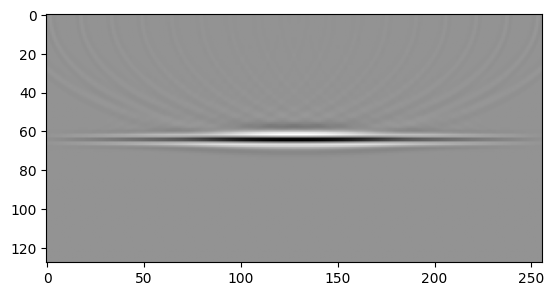

Python: <matplotlib.image.AxesImage object at 0x7f2aa299c8c0>

In [22]:
imshow(rtm_lin', cmap="gray")

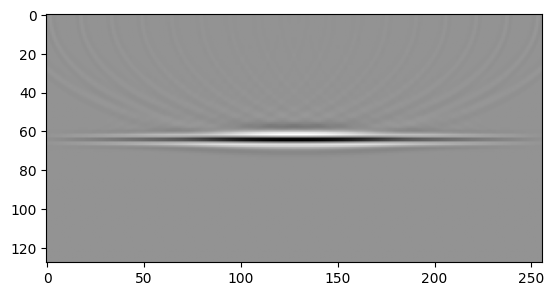

Python: <matplotlib.image.AxesImage object at 0x7f2a89c557c0>

In [23]:
imshow(cig_lin[26,:,:]', cmap="gray")

In [ ]:
using Test
nh  = n_offsets
ssodm = J_ext'*dlin
@test size(ssodm, 1) == nh

ssor = zeros(Float32, size(ssodm)...)
ssor[26, :, :] .= dm.data

dDe = J_ext*ssor
# @show norm(dDe - dD), norm(ssor[:] - dm[:])
a, b = dot(dlin, dDe), dot(ssodm[:], ssor[:])

@test (a-b)/(a+b) ≈ 0 atol=sqrt(eps(1f0)) rtol=0

In [47]:
niter = 2
x_elsrtm1 = similar(cig_lin, Float32, J_ext.n) #zeros(Float32, size(cig_lin))

@time lsqr!(x_elsrtm1, J_ext, dlin_ext; maxiter=niter)

(length(dm), J.model.n, length(J.offsets), length(J.dims)) = (1671168, (256, 128), 51, 1)
(length(dm), J.model.n, length(J.offsets), length(J.dims)) = (1671168, (256, 128), 51, 1)
(length(dm), J.model.n, length(J.offsets), length(J.dims)) = (1671168, (256, 128), 51, 1)
(length(dm), J.model.n, length(J.offsets), length(J.dims)) = (1671168, (256, 128), 51, 1)
(length(dm), J.model.n, length(J.offsets), length(J.dims)) = (1671168, (256, 128), 51, 1)
(length(dm), J.model.n, length(J.offsets), length(J.dims)) = (1671168, (256, 128), 51, 1)
(length(dm), J.model.n, length(J.offsets), length(J.dims)) = (1671168, (256, 128), 51, 1)
(length(dm), J.model.n, length(J.offsets), length(J.dims)) = (1671168, (256, 128), 51, 1)
(length(dm), J.model.n, length(J.offsets), length(J.dims)) = (1671168, (256, 128), 51, 1)
(length(dm), J.model.n, length(J.offsets), length(J.dims)) = (1671168, (256, 128), 51, 1)
(length(dm), J.model.n, length(J.offsets), length(J.dims)) = (1671168, (256, 128), 51, 1)
(length(dm

Operator `forward` ran in 0.04 s
Operator `cig_sso` ran in 1.05 s
Operator `forward` ran in 0.03 s
Operator `cig_sso` ran in 1.02 s
Operator `forward` ran in 0.04 s
Operator `cig_sso` ran in 1.03 s
Operator `forward` ran in 0.04 s
Operator `cig_sso` ran in 1.05 s
Operator `forward` ran in 0.04 s
Operator `cig_sso` ran in 1.03 s
Operator `forward` ran in 0.04 s
Operator `cig_sso` ran in 1.07 s
Operator `forward` ran in 0.03 s
Operator `cig_sso` ran in 1.04 s
Operator `forward` ran in 0.04 s
Operator `cig_sso` ran in 1.08 s
Operator `forward` ran in 0.04 s
Operator `cig_sso` ran in 1.27 s
Operator `forward` ran in 0.03 s
Operator `cig_sso` ran in 1.06 s
Operator `forward` ran in 0.03 s
Operator `cig_sso` ran in 1.09 s
Operator `forward` ran in 0.04 s
Operator `cig_sso` ran in 1.20 s
Operator `forward` ran in 0.05 s
Operator `cig_sso` ran in 1.09 s
Operator `forward` ran in 0.04 s
Operator `cig_sso` ran in 1.11 s
Operator `forward` ran in 0.04 s
Operator `cig_sso` ran in 1.07 s
Operator `

(1671168, (256, 128), 51, 1)


Operator `extborn` ran in 0.73 s


(length(dm), J.model.n, length(J.offsets), length(J.dims)) = (1671168, (256, 128), 51, 1)
(length(dm), J.model.n, length(J.offsets), length(J.dims)) = 

...

(1671168, (256, 128), 51, 1)


Operator `extborn` ran in 0.72 s


107.049523 seconds (6.82 M allocations: 688.910 MiB, 0.04% gc time)


Operator `extborn` ran in 0.72 s


PhysicalParameter{Float32, 3} of size (51, 256, 128) with origin (-300.0f0, 0.0f0, 0.0f0) and spacing (12.0f0, 12.5f0, 12.5f0)


In [26]:
function plot_cig(cig)
    d = (12.5f0, 12.5f0)

    cig_fs = 12

    # reshape data
    y = reshape(permutedims(cig, (2, 3, 1)), n[1], n[2], n_offsets, 1)

    # rc settings
    PythonPlot.rc("figure", titlesize=cig_fs)
    PythonPlot.rc("font", family="serif")
    PythonPlot.rc("xtick", labelsize=cig_fs)
    PythonPlot.rc("ytick", labelsize=cig_fs)
    PythonPlot.rc("axes", labelsize=cig_fs)
    PythonPlot.rc("axes", titlesize=cig_fs)

    # positions
    xpos = 1.5f3
    zpos = 0.8f3

    xgrid = Int(round(xpos / d[1]))
    zgrid = Int(round(zpos / d[2]))

    # subplots
    fig, axs = PythonPlot.subplots(
        2, 2,
        figsize=(20, 12),
        gridspec_kw=Dict("width_ratios" => [3, 1],
                         "height_ratios" => [1, 3])
    )

    # convert to Julia array (CRITICAL)
    axs = pyconvert(Array, axs)

    PythonPlot.subplots_adjust(hspace=0.0, wspace=0.0)

    # color scaling
    vmin1, vmax1 = (-1, 1) .* quantile(abs.(vec(y[:, zgrid, :, 1])), 0.99)
    vmin2, vmax2 = (-1, 1) .* quantile(abs.(vec(y[:, :, div(n_offsets,2)+1, 1])), 0.99)
    vmin3, vmax3 = (-1, 1) .* quantile(abs.(vec(y[xgrid, :, :, 1])), 0.99)

    # ======================
    # Top-left
    # ======================
    ax = axs[1,1]
    im1 = ax.imshow(
        y[:, zgrid, :, 1]',
        aspect="auto",
        cmap="gray",
        interpolation="none",
        vmin=vmin1,
        vmax=vmax1,
        extent=(0f0, (n[1]-1)*d[1], offset_start, offset_end)
    )

    ax.set_xticklabels([])
    ax.set_xlabel("")

    ax.hlines(0, 0, (n[1]-1)*d[1], colors="b", linewidth=3)
    ax.vlines(xpos, offset_start, offset_end, colors="b", linewidth=3)

    # ======================
    # Bottom-left
    # ======================
    ax = axs[2,1]
    im2 = ax.imshow(
        y[:, :, div(n_offsets,2)+1, 1]',
        aspect="auto",
        cmap="gray",
        interpolation="none",
        vmin=vmin2,
        vmax=vmax2,
        extent=(0f0, (n[1]-1)*d[1], (n[2]-1)*d[2], 0f0)
    )

    ax.set_xlabel("X [m]", fontsize=cig_fs)
    ax.set_ylabel("Z [m]", fontsize=cig_fs)

    ax.set_xticks([0, 500, 1000, 1500, 2000, 2500])
    ax.set_xticklabels(["0", "500", "1000", "1500", "2000", "2500"])
    ax.set_yticks([500, 1000, 1500])
    ax.set_yticklabels(["500", "1000", "1500"])

    ax.vlines(xpos, 0, (n[2]-1)*d[2], colors="b", linewidth=3)
    ax.hlines(zpos, 0, (n[1]-1)*d[1], colors="b", linewidth=3)

    # ======================
    # Top-right (hidden)
    # ======================
    axs[1,2].set_visible(false)

    # ======================
    # Bottom-right
    # ======================
    ax = axs[2,2]
    im3 = ax.imshow(
        y[xgrid, :, :, 1],
        aspect="auto",
        cmap="gray",
        interpolation="none",
        vmin=vmin3,
        vmax=vmax3,
        extent=(offset_start, offset_end, (n[2]-1)*d[2], 0f0)
    )

    ax.set_xlabel("Offset [m]", fontsize=cig_fs)
    ax.set_yticklabels([])
    ax.set_ylabel("")

    ax.vlines(0, 0, (n[2]-1)*d[2], colors="b", linewidth=3)
    ax.hlines(zpos, offset_end, offset_start, colors="b", linewidth=3)

    # ======================
    # Remove spines (safe)
    # ======================
    for ax in axs
        for spine in ["top", "right", "bottom", "left"]
            ax.spines[spine].set_visible(false)
        end
    end

    PythonPlot.show()
end

plot_cig (generic function with 1 method)

sys:1: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


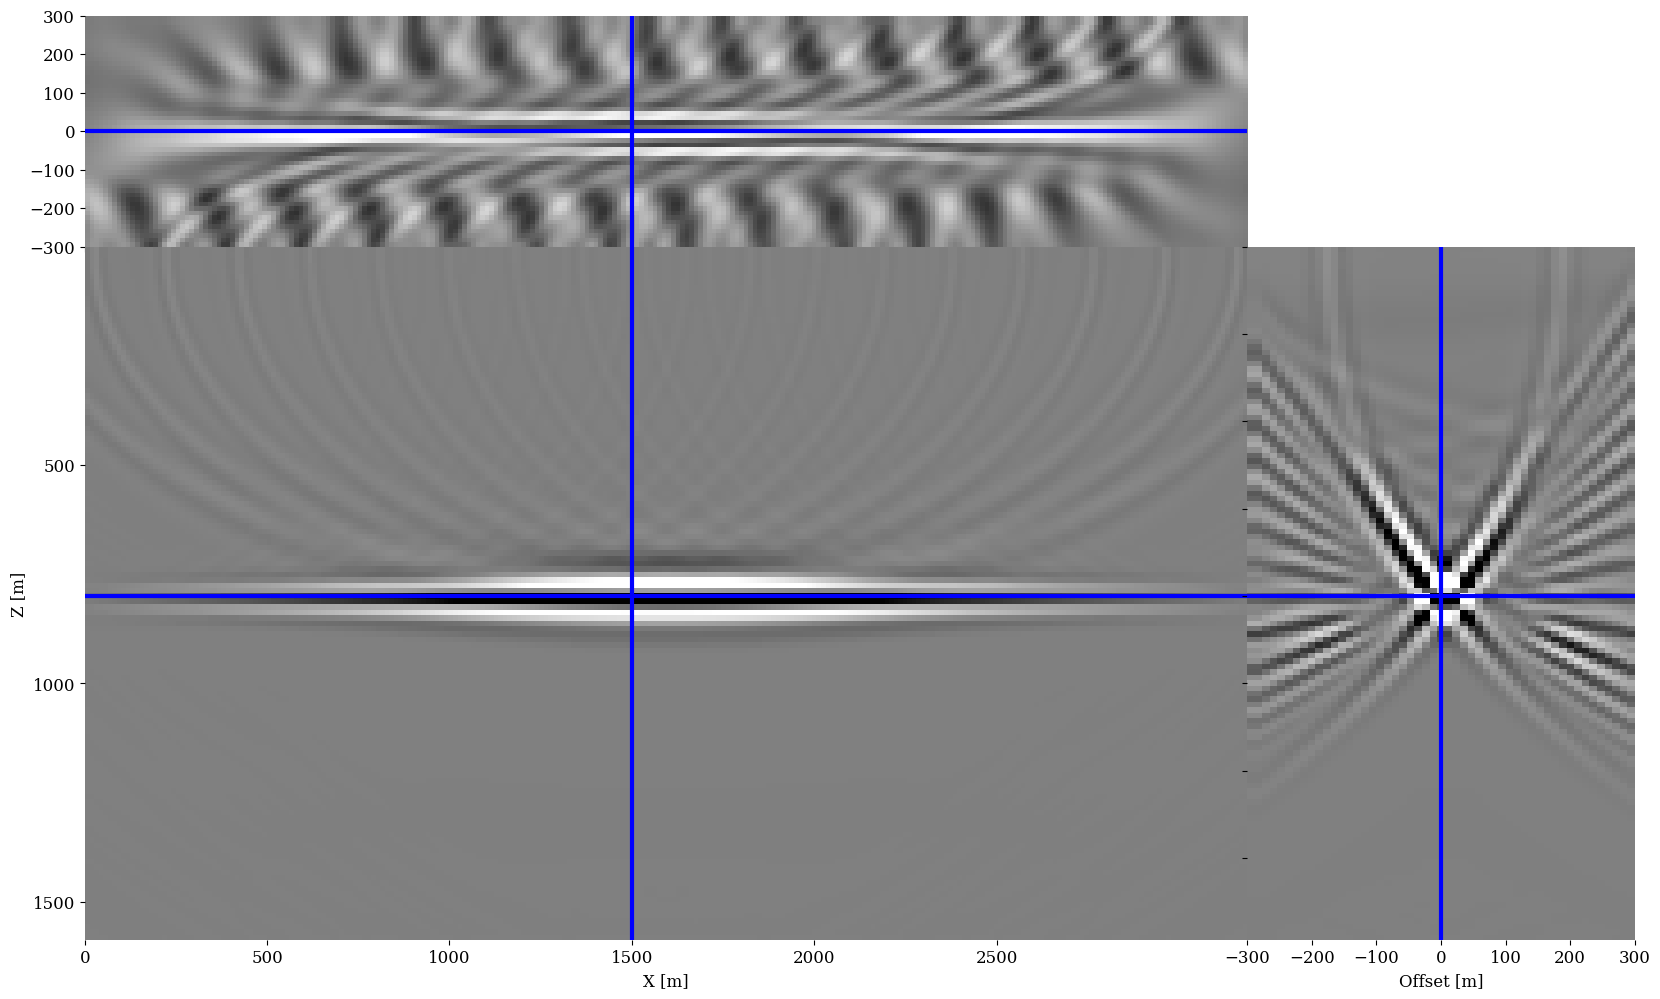

In [27]:
plot_cig(cig_lin)